# Introdução às Técnicas de Regressão

In [33]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_friedman1, make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures, StandardScaler

FIG_DIR = Path("figuras_regressao")
FIG_DIR.mkdir(exist_ok=True)
for old_png in FIG_DIR.glob("*.png"):
    old_png.unlink()

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 220,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

RNG = np.random.default_rng(42)

def savefig(name):
    plt.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()

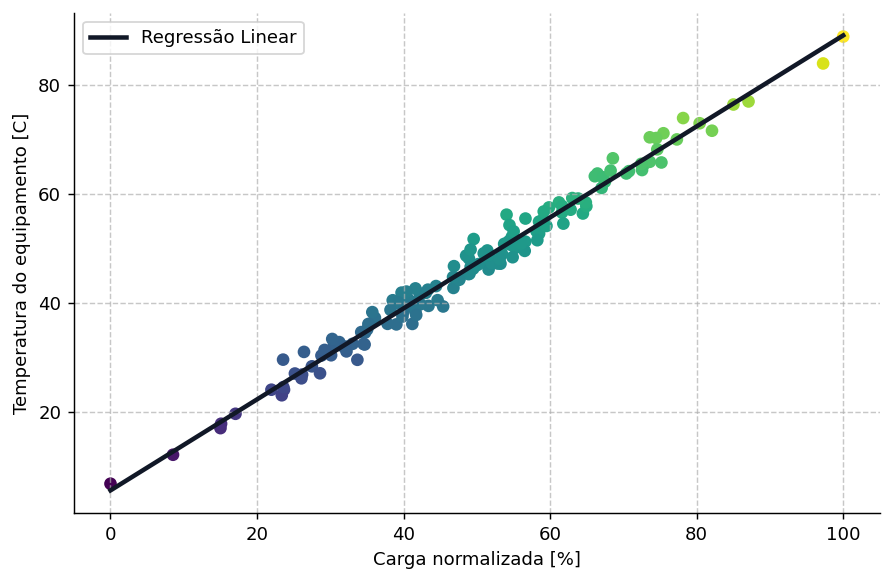

In [55]:
# Figura 1: alvo numérico em regressao.
X, y_raw = make_regression(
    n_samples=150,
    n_features=1,
    noise=18.0,
    random_state=12,
)
X = MinMaxScaler().fit_transform(X) * 100
y = 0.50 * X.ravel() + 22 + (y_raw - y_raw.mean()) / y_raw.std() * 6

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1
)

modelo_linear = LinearRegression()
modelo_linear.fit(X_train, y_train)

x_grid = np.linspace(0, 100, 300).reshape(-1, 1)
y_grid = modelo_linear.predict(x_grid)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, c=y)
plt.plot(x_grid[:, 0], y_grid, color="#111827", lw=2.5, label="Regressão Linear")
plt.xlabel("Carga normalizada [%]")
plt.ylabel("Temperatura do equipamento [C]")
plt.grid(True, linestyle="--", linewidth=0.8, alpha=0.7)
plt.legend(frameon=True)
savefig("regressao_numerico")
plt.show()

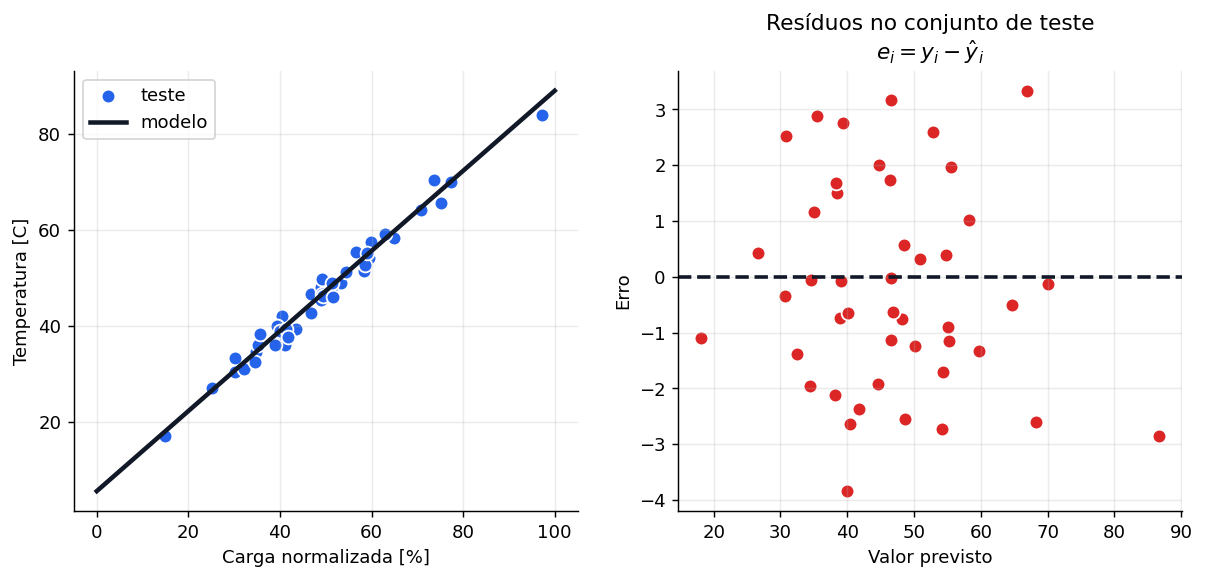

In [63]:
# Figura 2: residuos como erros de previsao.
y_pred_test = modelo_linear.predict(X_test)
residuos = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

axes[0].scatter(X_test[:, 0], y_test, c="#2563eb", edgecolor="white", s=58, label="teste")
axes[0].plot(x_grid[:, 0], y_grid, color="#111827", lw=2.5, label="modelo")
axes[0].set_xlabel("Carga normalizada [%]")
axes[0].set_ylabel("Temperatura [C]")
axes[0].legend(frameon=True)

axes[1].scatter(y_pred_test, residuos, c="#dc2626", edgecolor="white", s=58)
axes[1].axhline(0, color="#111827", lw=2, ls="--")
axes[1].set_title("Resíduos no conjunto de teste\n" + r"$e_i = y_i - \hat{y}_i$")
axes[1].set_xlabel("Valor previsto")
axes[1].set_ylabel("Erro")

savefig("residuos_regressao")

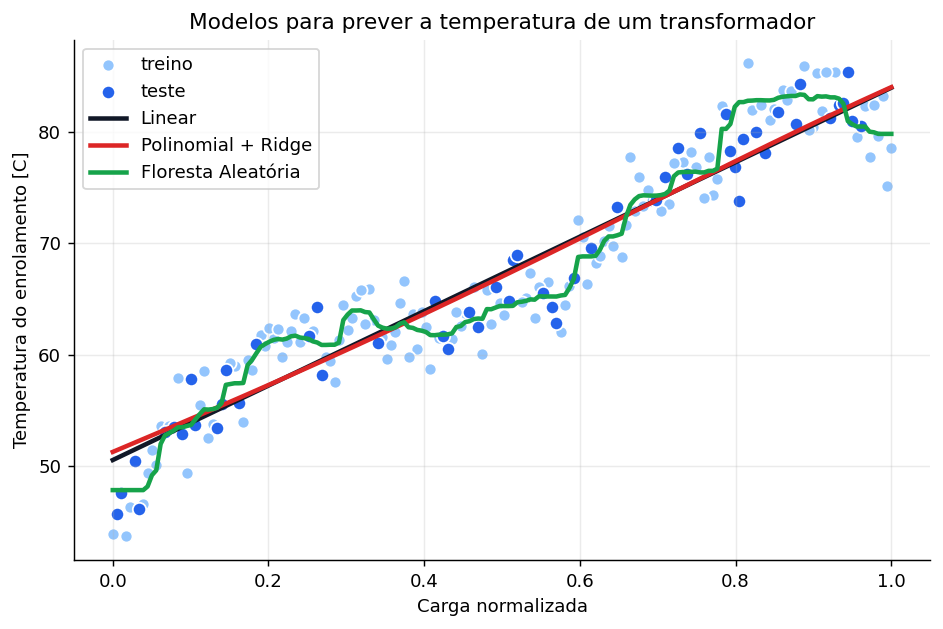

In [48]:
# Figura 4: modelos lineares e nao lineares para prever temperatura de um transformador.
x = np.linspace(0, 1, 180).reshape(-1, 1)

# Interpretacao didatica:
# x = carga normalizada do transformador
# y = temperatura do enrolamento [C]
y_curve = 55 + 28 * x.ravel() - 30 * (x.ravel() - 0.60) ** 2 + 5 * np.sin(9 * x.ravel())
y_obs = y_curve + 1.3*RNG.normal(0, 1.7, size=x.shape[0])

X_train_curve, X_test_curve, y_train_curve, y_test_curve = train_test_split(
    x, y_obs, test_size=0.30, random_state=4
)

modelos_curva = {
    "Linear": LinearRegression(),
    "Polinomial + Ridge": make_pipeline(
        PolynomialFeatures(degree=4, include_bias=False),
        StandardScaler(),
        Ridge(alpha=0.7),
    ),
    "Floresta Aleatória": RandomForestRegressor(n_estimators=120, min_samples_leaf=4, random_state=4),
}

fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.scatter(X_train_curve[:, 0], y_train_curve, c="#93c5fd", edgecolor="white", s=45, label="treino")
ax.scatter(X_test_curve[:, 0], y_test_curve, c="#2563eb", edgecolor="white", s=55, label="teste")

cores = {"Linear": "#111827", "Polinomial + Ridge": "#dc2626", "Floresta Aleatória": "#16a34a"}
for nome, modelo in modelos_curva.items():
    modelo.fit(X_train_curve, y_train_curve)
    ax.plot(x[:, 0], modelo.predict(x), lw=2.5, color=cores[nome], label=nome)

ax.set_title("Modelos para prever a temperatura de um transformador")
ax.set_xlabel("Carga normalizada")
ax.set_ylabel("Temperatura do enrolamento [C]")
ax.legend(frameon=True)
savefig("modelos_curvas_regressao")

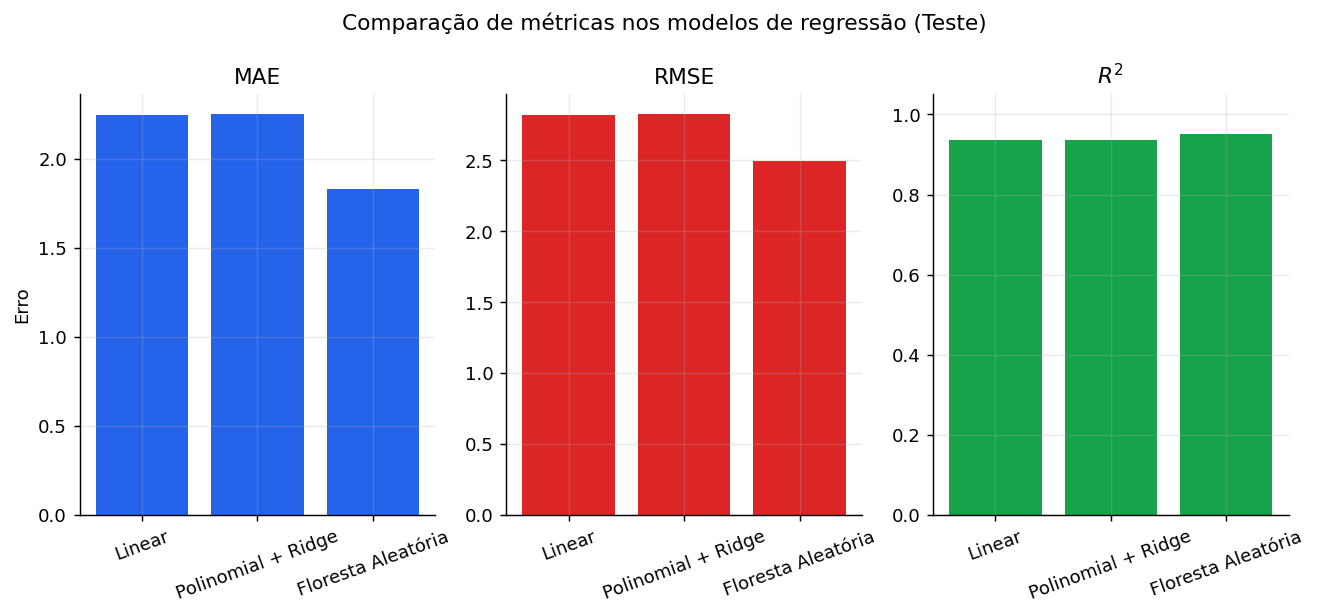

,Modelo,MAE,RMSE,$R^2$
0,Linear,2.615,3.195,0.920
1,Polinomial + Ridge,2.622,3.201,0.919
2,Floresta Aleatória,1.607,2.044,0.967


In [64]:
# Figura 5: comparação de métricas entre os modelos de regressão já estudados.
nomes, maes, rmses, r2s = [], [], [], []

for nome, modelo in modelos_curva.items():
    modelo.fit(X_train_curve, y_train_curve)
    y_pred_curve = modelo.predict(X_test_curve)

    nomes.append(nome)
    maes.append(mean_absolute_error(y_test_curve, y_pred_curve))
    rmses.append(root_mean_squared_error(y_test_curve, y_pred_curve))
    r2s.append(r2_score(y_test_curve, y_pred_curve))

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))

axes[0].bar(nomes, maes, color="#2563eb")
axes[0].set_title("MAE")
axes[0].set_ylabel("Erro")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(nomes, rmses, color="#dc2626")
axes[1].set_title("RMSE")
axes[1].tick_params(axis="x", rotation=20)

axes[2].bar(nomes, r2s, color="#16a34a")
axes[2].set_title(r"$R^2$")
axes[2].set_ylim(0, 1.05)
axes[2].tick_params(axis="x", rotation=20)

fig.suptitle("Comparação de métricas nos modelos de regressão (Teste)", y=1.03)
savefig("metricas_modelos_regressao")

df_metricas


In [52]:
# Exemplo minimo especifico de regressao com sklearn.
modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.2f}")
print(f"R2: {r2_score(y_test, y_pred):.3f}")
print("Primeiras previsoes:", np.round(y_pred[:8], 2))

MAE: 1.54
RMSE: 1.84
R2: 0.978
Primeiras previsoes: [34.59 55.24 44.71 55.14 39.31 26.61 38.9  50.18]
